In [1]:
import torch
import torch.optim as optim
from torch.utils.data import DataLoader
from sklearn.decomposition import PCA
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import numpy as np
import json
import os

from Encoder import*
from Tools.model_tools import load_configs
from Tools.data_utils import extract_params_from_filename
from Tools.mathematical_tools import denormalize_columns, diagonal_mean, reconstruct_time_series
from Tools.analysis_tools import*

In [2]:
# Percorso del database
decoder_database_path = "decoderDatabaseZ3.json"

# Carica tutte le configurazioni disponibili
all_decoder = load_configs(decoder_database_path)

# Visualizza le configurazioni disponibili
for model_name, config in all_decoder.items():
    print(model_name, config)

Model_1 {'decoder_layers': [5, 10, 15, 20], 'latent_dim': 5, 'early_stopping': {'patience': 10, 'delta': -1}, 'dataset': 'delay3dim100,20_noise0,0', 'batch_size': 32, 'optimizer': 'Adam', 'learning_rate': 0.02, 'scheduler': {'type': 'ReduceLROnPlateau', 'params': {'mode': 'min', 'factor': 0.5, 'patience': 10, 'min_lr': 1e-09, 'base_lr': 0.0001, 'max_lr': 0.01, 'step_size_up': 200, 'T_max': 100, 'T_0': 10, 'T_mult': 2, 'eta_min': 1e-08}}, 'Encoder': 'Model_1'}
30-20 {'decoder_layers': [5, 10, 15, 20], 'latent_dim': 5, 'early_stopping': {'patience': 10, 'delta': -1}, 'dataset': 'delay3dim30,20_noise0,0', 'batch_size': 32, 'optimizer': 'Adam', 'learning_rate': 0.02, 'scheduler': {'type': 'ReduceLROnPlateau', 'params': {'mode': 'min', 'factor': 0.5, 'patience': 10, 'min_lr': 1e-09, 'base_lr': 0.0001, 'max_lr': 0.01, 'step_size_up': 200, 'T_max': 100, 'T_0': 10, 'T_mult': 2, 'eta_min': 1e-08}}, 'Encoder': '30-20'}


In [3]:
# Scegli un modello specifico
decoder_name = "30-20"  # Cambia con il nome desiderato
decoder_config = all_decoder.get(decoder_name)

if decoder_config is None:
    raise ValueError(f"Il modello {decoder_name} non esiste nel database.")

print(f"Il decoder è stato allenato con il modello Encoder : {decoder_config["Encoder"]}" )

Il decoder è stato allenato con il modello Encoder : 30-20


Loading network and database from the Encoder Models folder

In [4]:
# Percorso al file del decoder salvato
decoder_file_path = os.path.join("Decoder Models Z3", f"{decoder_name}.pth")
decoder, decoder_checkpoint = load_decoderZ3(decoder_file_path, Decoder)

params = extract_params_from_filename(decoder_config["dataset"])
print(f"Parametri del dataset: {params}")
tau = params["tau"]
embedding_dim = params["embedding_dim"]
r = params["r"]

decoder_epoch = decoder_checkpoint['epoch']
decoder_stopped_epoch = decoder_checkpoint['stopped_epoch']
decoder_train_losses = decoder_checkpoint['train_losses']
decoder_val_losses = decoder_checkpoint['val_losses']
decoder_gradient_history = decoder_checkpoint['gradient_history']

Decoder and training info loaded from Decoder Models Z3/30-20.pth
Parametri del dataset: {'tau': 3, 'embedding_dim': 30, 'r': 20, 'alpha': 0.0, 'beta': 0.0}


/workspaces/Lorenz-Toy/Tools/training_tools.py:538: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(file_path)


In [5]:
#Scelta dell'Encoder da concatenare al Decoder selezionato:
encoder_database_path = "encoderDatabase.json"
all_encoders = load_configs(encoder_database_path)

for model_name, config in all_encoders.items():
    print(model_name, config)

encoder_name = decoder_config["Encoder"] # Cambia per cambiare l'encoder concatenato

encoder_config = all_encoders.get(encoder_name)
if encoder_config is None:
    raise ValueError(f"Il modello {decoder_config["Encoder"]} non esiste nel database.")

if encoder_config["latent_dim"] != decoder_config["latent_dim"]:
    raise ValueError("Le dimensioni latenti dell'encoder e del decoder non coincidono.")

print(f" Si è caricato l'Encoder: {encoder_name}")


#Caricamento del modello preallenato dell'encoder
encoder_model_path = "Encoder Models"
encoder_path = os.path.join(encoder_model_path, encoder_name + ".pth")

encoder, encoder_checkpoint = load_encoder(encoder_path, Encoder)

encoder_epoch = encoder_checkpoint['epoch']
encoder_stopped_epoch = encoder_checkpoint['stopped_epoch']
encoder_train_losses = encoder_checkpoint['train_losses']
encoder_val_losses = encoder_checkpoint['val_losses']
recon_losses = encoder_checkpoint['recon_losses']
kld_losses = encoder_checkpoint['kld_losses']
effective_kld_losses = encoder_checkpoint['effective_kld_losses']
beta_values = encoder_checkpoint['beta_values']
encoder_gradient_history = encoder_checkpoint['gradient_history']
H2_1 = encoder_checkpoint['H2_1']
H2_2 = encoder_checkpoint['H2_2']
H1= encoder_checkpoint['H1']
denormalizing_params = encoder_checkpoint['denormalizing_params']
P = encoder_checkpoint['P']


Model_1 {'layer_dims': [20, 15, 10, 5], 'latent_dim': 5, 'beta_method': 'sigmoid', 'beta_value': 0.01, 'kl_annealing_epochs': 250, 'decay_start': 100, 'decay_epoch': 50, 'early_stopping': {'patience': 10, 'delta': -1}, 'dataset': 'delay3dim100,20_noise0,0', 'batch_size': 32, 'optimizer': 'Adam', 'learning_rate': 0.02, 'scheduler': {'type': 'ReduceLROnPlateau', 'params': {'mode': 'min', 'factor': 0.5, 'patience': 10, 'min_lr': 1e-09, 'base_lr': 0.0001, 'max_lr': 0.01, 'step_size_up': 200, 'T_max': 100, 'T_0': 10, 'T_mult': 2, 'eta_min': 1e-08}}}
NoLeg {'layer_dims': [20, 15, 10, 5], 'latent_dim': 5, 'beta_method': 'sigmoid', 'beta_value': 0.01, 'kl_annealing_epochs': 250, 'decay_start': 100, 'decay_epoch': 50, 'early_stopping': {'patience': 10, 'delta': -1}, 'dataset': 'delay3dim20,20_noise0,0', 'batch_size': 32, 'optimizer': 'Adam', 'learning_rate': 0.02, 'scheduler': {'type': 'ReduceLROnPlateau', 'params': {'mode': 'min', 'factor': 0.5, 'patience': 10, 'min_lr': 1e-09, 'base_lr': 0.00

/workspaces/Lorenz-Toy/Tools/training_tools.py:383: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(path)


In [6]:
batch_size = decoder_config["batch_size"]

train_data = decoder_checkpoint["train_data"]
val_data = decoder_checkpoint["val_data"]

train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False)

total_sample = len(train_data)+len(val_data)
print(f"Numero totale di campioni: {total_sample}")
print(f"Numero di campioni di training: {len(train_data)}")
print(f"Numero di campioni di validazione: {len(val_data)}")

Numero totale di campioni: 9913
Numero di campioni di training: 5947
Numero di campioni di validazione: 3966


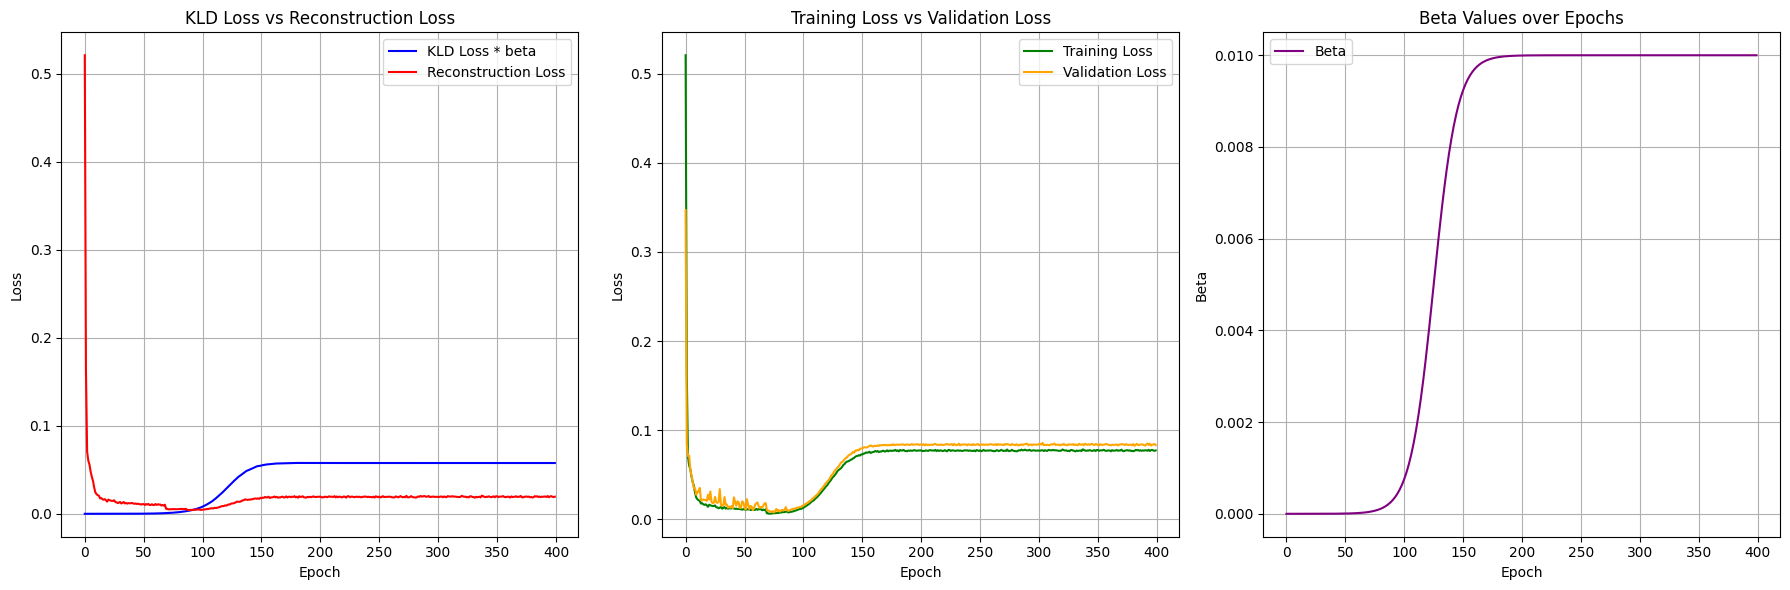

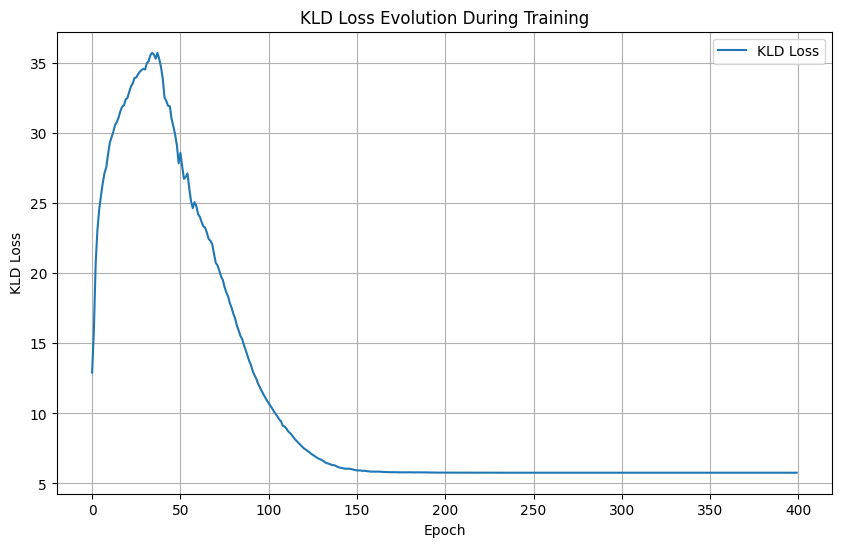

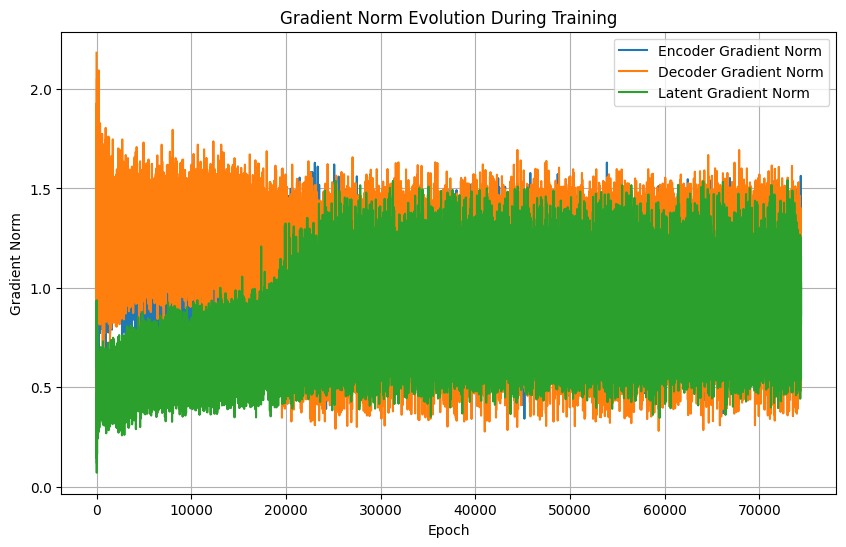

In [7]:
plot_results(encoder_train_losses, encoder_val_losses, recon_losses, kld_losses,effective_kld_losses, beta_values, encoder_gradient_history)

In [8]:
# Calling a VAE instance from pre-trained encoder and decoder
vae_model = VAE(encoder, decoder)

input_data, predicted_data, mean_vectors, logvar_vectors = run_model_and_collect_outputs(vae_model, val_loader, device="cpu")

predicted_data_matrix = predicted_data.T

print("Input data shape:", input_data.shape)
print("Predicted data shape:", predicted_data.shape)
print("Mean vectors shape:", mean_vectors.shape)
print("Logvar vectors shape:", logvar_vectors.shape)


# Input and target definition from the validation data
inputs, targets = zip(*[val_data[i] for i in range(len(val_data))])  # Not very useful now, but it will be in the future  

# Convert into Numpy tensor for analysis
inputs = torch.stack(inputs).numpy() 
targets = torch.stack(targets).numpy()

print("Inputs shape:", inputs.shape)
print("Targets shape:", targets.shape)

Input data shape: (3966, 20)
Predicted data shape: (3966, 20)
Mean vectors shape: (3966, 5)
Logvar vectors shape: (3966, 5)
Inputs shape: (3966, 20)
Targets shape: (3966, 20)


In [9]:
from numpy.linalg import pinv

# Ottieni gli indici delle colonne di validazione
validation_indices = val_data.indices
original_Hankel_Matrix = H2_2[:, validation_indices]

# Estrai i minimi e massimi per le colonne di validazione
validation_min_vals = denormalizing_params["min_h2_2"][:, validation_indices]
validation_max_vals = denormalizing_params["max_h2_2"][:, validation_indices]

print("Validation Min Values shape:", validation_min_vals.shape)

# Denormalizza usando i valori specifici
predicted_data_matrix = denormalize_columns(predicted_data_matrix, validation_min_vals, validation_max_vals)

# Calcola la pseudo-inversa di P
P_pseudo_inverse = pinv(P)

# Check delle shape:
print("Legendre Basis Matrix Shape (d x r):" , P.shape)
print("Pseudo-inverse of P shape (r x d):", P_pseudo_inverse.shape)
print("Input data Matrix shape:", original_Hankel_Matrix.shape)
print("Predicted data Matrix shape:", predicted_data_matrix.shape)

# Reverse projection of the predicted Matrix using pseudo-inverse of P
predicted_reconstructed_hankel = np.dot(predicted_data_matrix.T, P_pseudo_inverse) 
predicted_reconstructed_hankel = predicted_reconstructed_hankel.T
print("Predicted Reconstructed Hankel shape:", predicted_reconstructed_hankel.shape)



Validation Min Values shape: (1, 3966)
Legendre Basis Matrix Shape (d x r): (30, 20)
Pseudo-inverse of P shape (r x d): (20, 30)
Input data Matrix shape: (30, 3966)
Predicted data Matrix shape: (20, 3966)
Predicted Reconstructed Hankel shape: (30, 3966)


r2_score entries: 3966


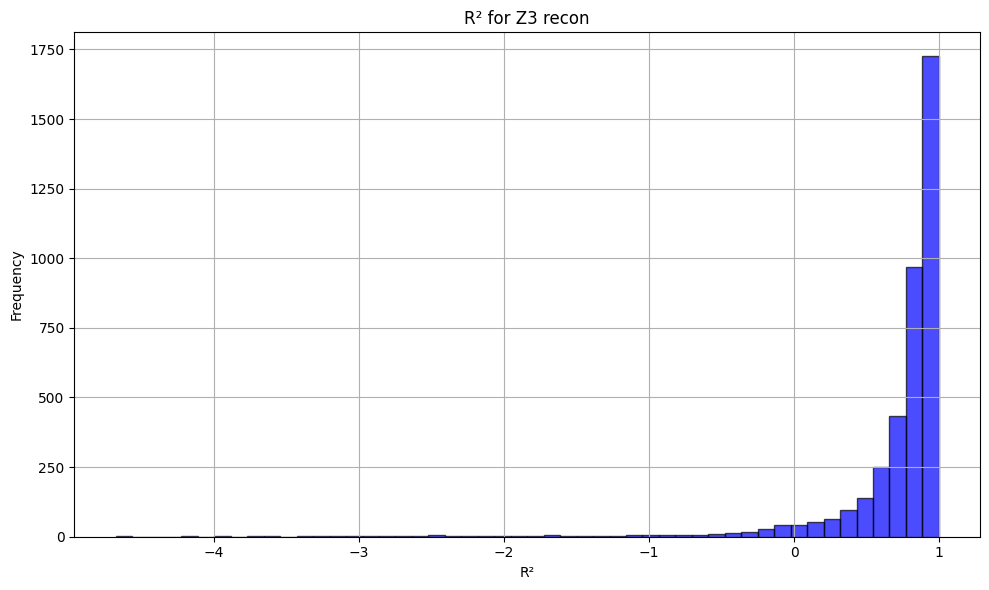

Indices of the 3 samples with the worst R² (z1): [2043  852 1835]
Mean R² for Z3 recon: 0.7139334 pm 0.4883081


In [10]:
# Plot the R² histogram and get the indices of the worst R² samples
worst_r2_indices1, r2_scores1 = plot_r2_histogram(targets,predicted_data)
mean_r21 = np.mean(r2_scores1)
std_r21 = np.std(r2_scores1)

fig, ax = plt.subplots(figsize=(10, 6))

# Plot R² histogram for Z1 recon
ax.hist(r2_scores1, bins=50, alpha=0.7, color='blue', edgecolor='black')
ax.set_title('R² for Z3 recon')
ax.set_xlabel('R²')
ax.set_ylabel('Frequency')
ax.grid(True)

plt.tight_layout()
plt.show()

print("Indices of the 3 samples with the worst R² (z1):", worst_r2_indices1)
print("Mean R² for Z3 recon:", mean_r21 , "pm", std_r21)




Entries: 3966


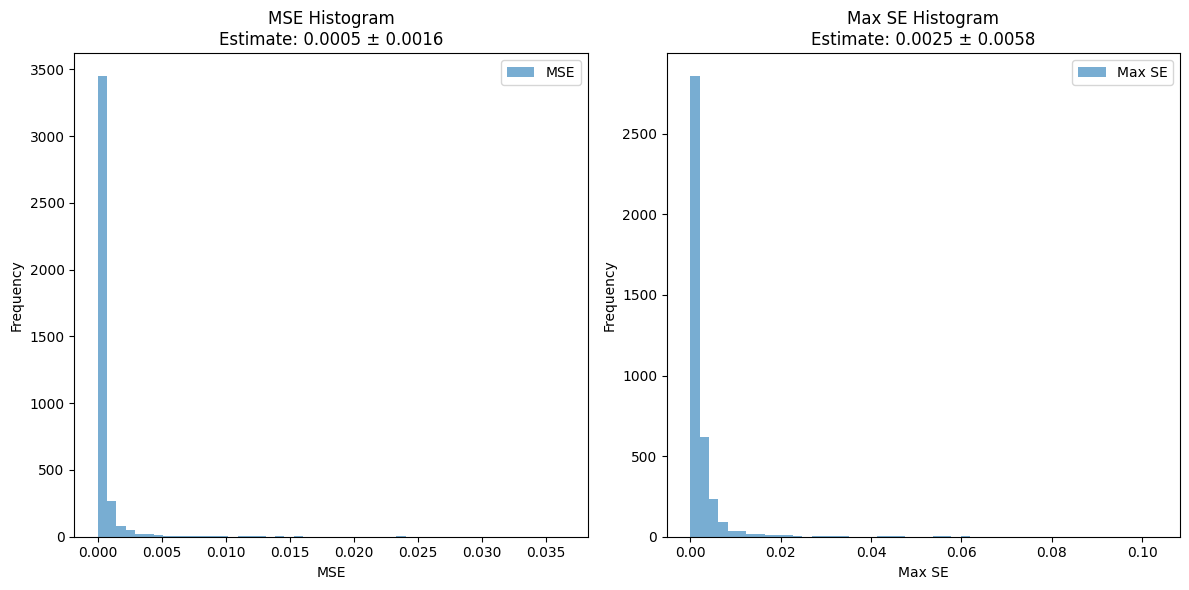

Indices of the 3 samples with the worst MAXse: [163 162 171]
Mean MSE for Z2 recon: 0.0005189491 pm 0.001586895
Mean MAXse for Z2 recon: 0.0024954223 pm 0.0058141686


In [11]:
# Calculate errors and plot histogram for Z1 recon
worst_max_se_indices1, best_mse_indices1, mse_errors1, max_se_errors1 = calculate_errors_and_plot_hist(targets, predicted_data)
mean_mse = mse_errors1.mean()
std_mse = mse_errors1.std()
mean_max_se = max_se_errors1.mean()
std_max_se = max_se_errors1.std()
print("Indices of the 3 samples with the worst MAXse:", worst_max_se_indices1)

print("Mean MSE for Z2 recon:", mean_mse , "pm", std_mse)
print("Mean MAXse for Z2 recon:", mean_max_se , "pm", std_max_se)


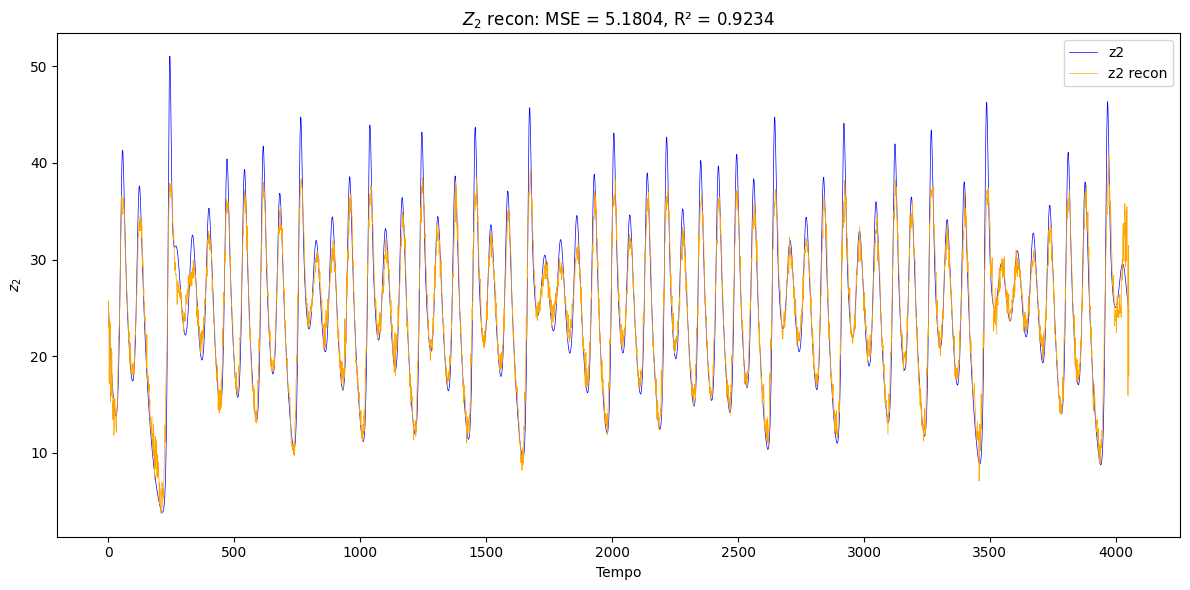

In [12]:
# Ricostruzione di Z2 dal suo embedding (Validation data)
val_Z2 = reconstruct_signal_from_embedding(original_Hankel_Matrix.T, embedding_dim,tau) #Diagonal Mean for Relaxed Formalism

# Ricostruzione di Z2 dal suo embedding (Ricostruito)
recon_Z2 = reconstruct_signal_from_embedding(predicted_reconstructed_hankel.T,embedding_dim,tau) #Diagonal Mean for Relaxed Formalism


# Calcola l'errore quadratico medio
mse1 = np.mean((val_Z2 - recon_Z2) ** 2)
r2_1 = r2_score(val_Z2, recon_Z2)
fig, ax = plt.subplots(figsize=(12, 6))

# Segnale y2(1)
ax.plot(val_Z2, label="z2", color='blue', lw=0.5)
ax.plot(recon_Z2, label="z2 recon", color='orange', lw=0.5)
ax.legend()
ax.set_title(r"$Z_2$ recon: MSE = {:.4f}, R² = {:.4f}".format(mse1, r2_1))
ax.set_xlabel("Tempo")
ax.set_ylabel("$z_2$")

plt.tight_layout()
plt.show()


In [13]:
def plot_pcs(original_signal, original_embeddings, reconstructed_embeddings, n_components=3):
    """
    Plotta il segnale temporale originale, le PC calcolate dagli embedding originali,
    e le PC ricostruite dagli embedding di output della rete per ogni componente principale.
    
    Parameters:
        original_signal (np.ndarray): Segnale temporale originale (1D array).
        original_embeddings (np.ndarray): Embedding del segnale originale (2D array).
        reconstructed_embeddings (np.ndarray): Embedding ricostruito dalla rete (2D array).
        n_components (int): Numero di componenti principali da calcolare.
    """
    # PCA sugli embedding originali
    pca = PCA(n_components=n_components)
    pc_original = pca.fit_transform(original_embeddings)  # Tutte le PC dagli embedding originali
    pc_reconstructed = pca.transform(reconstructed_embeddings)  # Proiezione delle PC ricostruite

    # Plot per ogni componente principale
    for i in range(n_components):
        # Calcola R^2 tra la PC originale e quella ricostruita
        r2 = r2_score(pc_original[:, i], pc_reconstructed[:, i])

        # Plot
        plt.figure(figsize=(12, 6))
        #plt.plot(original_signal, label='Input signal', color='black', lw=1.5)
        plt.plot(pc_original[:, i], label=f'PC{i+1} ', color='orange', lw=1.5)
        plt.plot(pc_reconstructed[:, i], label=f'PC{i+1} recon', linestyle='--', color='blue', alpha=0.7, lw=1.5)
        plt.title(f"Confronto tra Segnale Temporale e PC{i+1} Ricostruite - $R^2$: {r2:.2f}")
        plt.xlabel("Time (t)")
        plt.ylabel("Amplitude")
        plt.legend()
        plt.grid(True)
        plt.show()


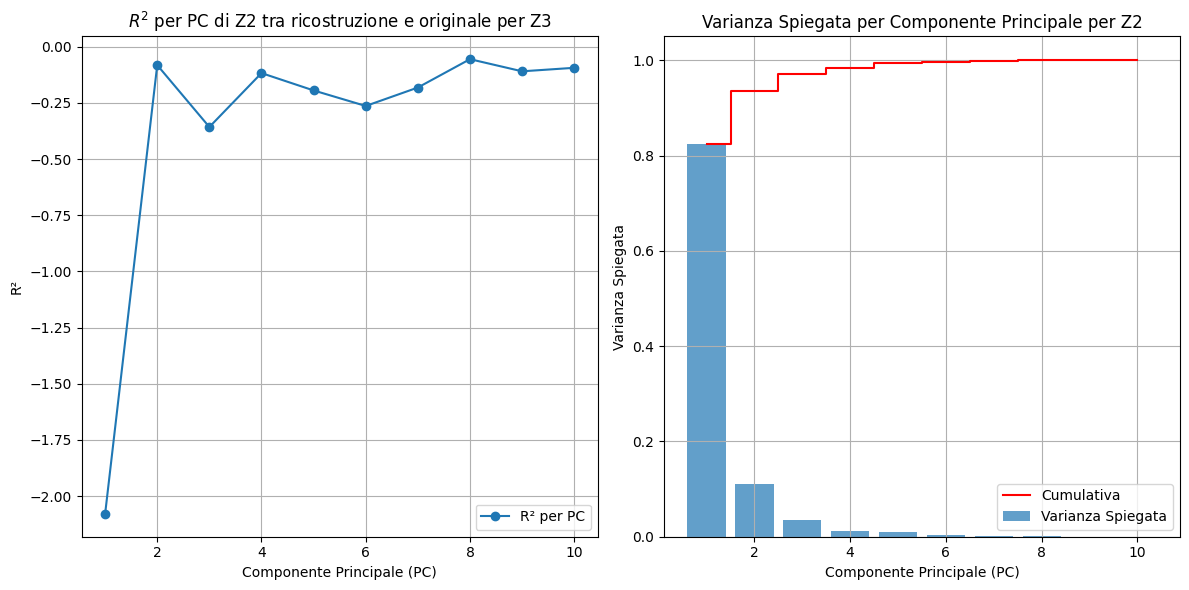

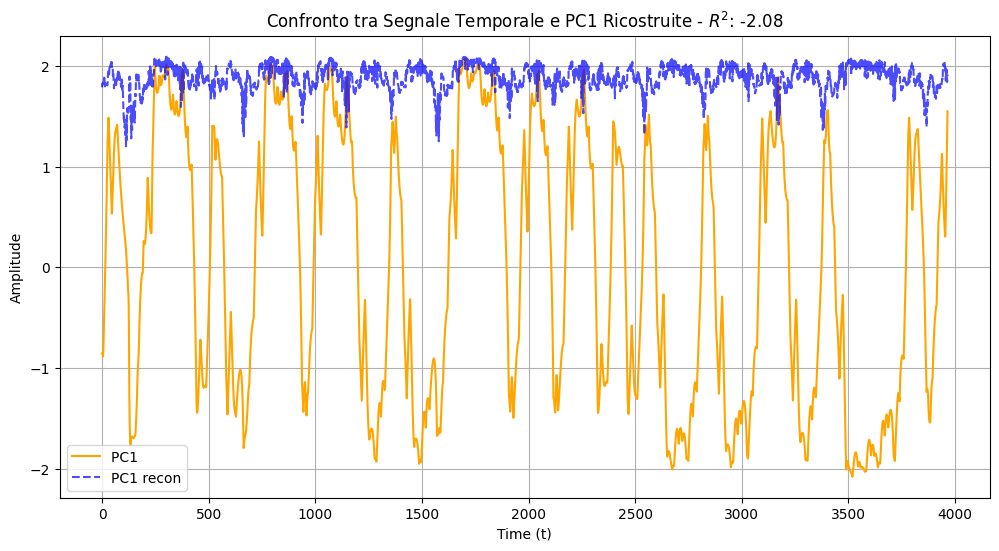

In [14]:
# Confronta PC per Z1
title1 = f"$R^2$ per PC di Z2 tra ricostruzione e originale per Z3"
title2 = f"Varianza Spiegata per Componente Principale per Z2"
r2_z1, ind2 = pca_r2_analysis_embeddings(inputs, predicted_data,title1,title2, n_components=10)
plot_pcs(val_Z2, inputs, predicted_data, n_components=1)

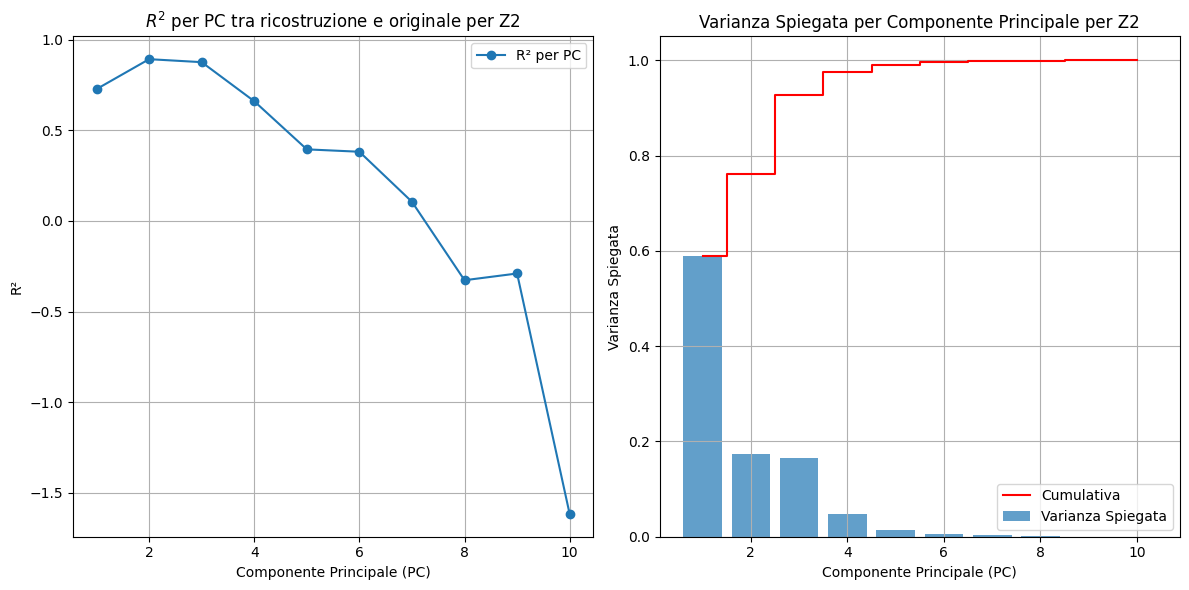

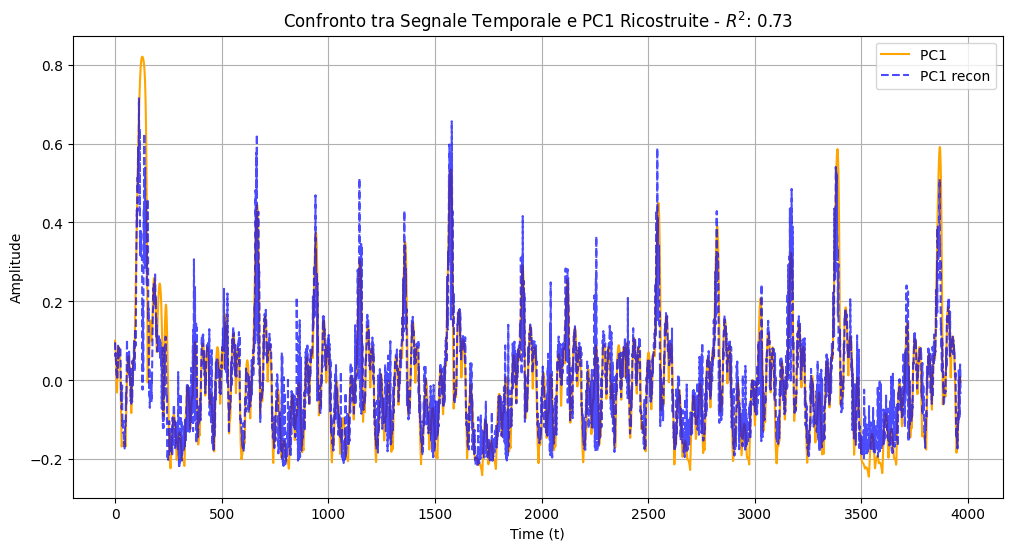

In [15]:
# Confronta PC per Z1
title1 = f"$R^2$ per PC tra ricostruzione e originale per Z2"
title2 = f"Varianza Spiegata per Componente Principale per Z2"
r2_z1, ind2 = pca_r2_analysis_embeddings(targets, predicted_data,title1,title2, n_components=10)
plot_pcs(val_Z2, targets, predicted_data, n_components=1)